# 6 &middot; Advanced PM: PGD Correction & Shell Strategies

This notebook assembles a production-style spherical lightcone and adds two ingredients that
matter for accurate maps:

- **PGD correction** (`PGDKernel`) — sharpens halo profiles that the finite PM force resolution
  would otherwise smooth out, restoring small-scale power;
- **shell partitioning** — how the comoving volume is sliced into shells (equal width vs equal
  volume vs the hybrid `jax_fli` default).


In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

import jax_fli as jfli

jax.config.update("jax_enable_x64", False)

/lustre/fswork/projects/rech/tkc/commun/venv/pm/lib/python3.11/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(


E0609 17:54:14.513121  272080 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0609 17:54:14.513699  272079 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0609 17:54:14.513771  272078 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Configuration

In [2]:
key = jax.random.PRNGKey(0)
mesh_size = (512, 512, 512)
box_size = (2000.0, 2000.0, 2000.0)
nside = 512
nb_shells = 8
cosmo = jc.Planck18()

## Sharding, initial conditions, LPT

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
)
t0 = 0.1
dx, p = jfli.lpt(cosmo, initial_field, ts=t0, order=1)
print(f"LPT at a={t0}, mesh={mesh_size}, box={box_size[0]} Mpc/h")

LPT at a=0.1, mesh=(512, 512, 512), box=2000.0 Mpc/h


## The advanced solver: OnionTiler + PGD

- **`OnionTiler`** replicates and rotates the periodic box so a full-sky shell is painted
  without boundary artefacts (see [notebook 5](05-PM-Interpolation.ipynb)).
- **`PGDKernel`** (Potential Gradient Descent) nudges particle positions after each drift to
  restore the small-scale power the PM force resolution loses. It has three tunable numbers,
  `alpha` (strength), `kl` (large-scale cutoff) and `ks` (small-scale cutoff); they are
  *differentiable*, so they can be calibrated against a reference simulation.

It is dropped into the solver via the `pgd_kernel` argument — the rest of the pipeline is
unchanged.

In [4]:
solver = jfli.DoubleKickDrift(
    interp_kernel=jfli.OnionTiler(
        painting=jfli.PaintingOptions(target="spherical", scheme="ngp"),
        drift_on_lightcone=False,
    ),
    pgd_kernel=jfli.PGDKernel(alpha=0.3),  # <-- small-scale sharpening
    t0=t0,
    t1=1.0,
    n_steps=18,
)

## Run the lightcone

We slice the volume into `nb_shells` shells with the default **equal-comoving-width** spacing
and paint each onto a HEALPix map during the integration.

In [5]:
lightcone = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="comoving")
print(f"{type(lightcone).__name__}  shape={lightcone.shape}")
print("comoving centers [Mpc/h]:", np.asarray(lightcone.comoving_centers).round(0))

SphericalDensity  shape=(8, 3145728)
comoving centers [Mpc/h]: [ 62. 188. 312. 438. 562. 688. 812. 938.]


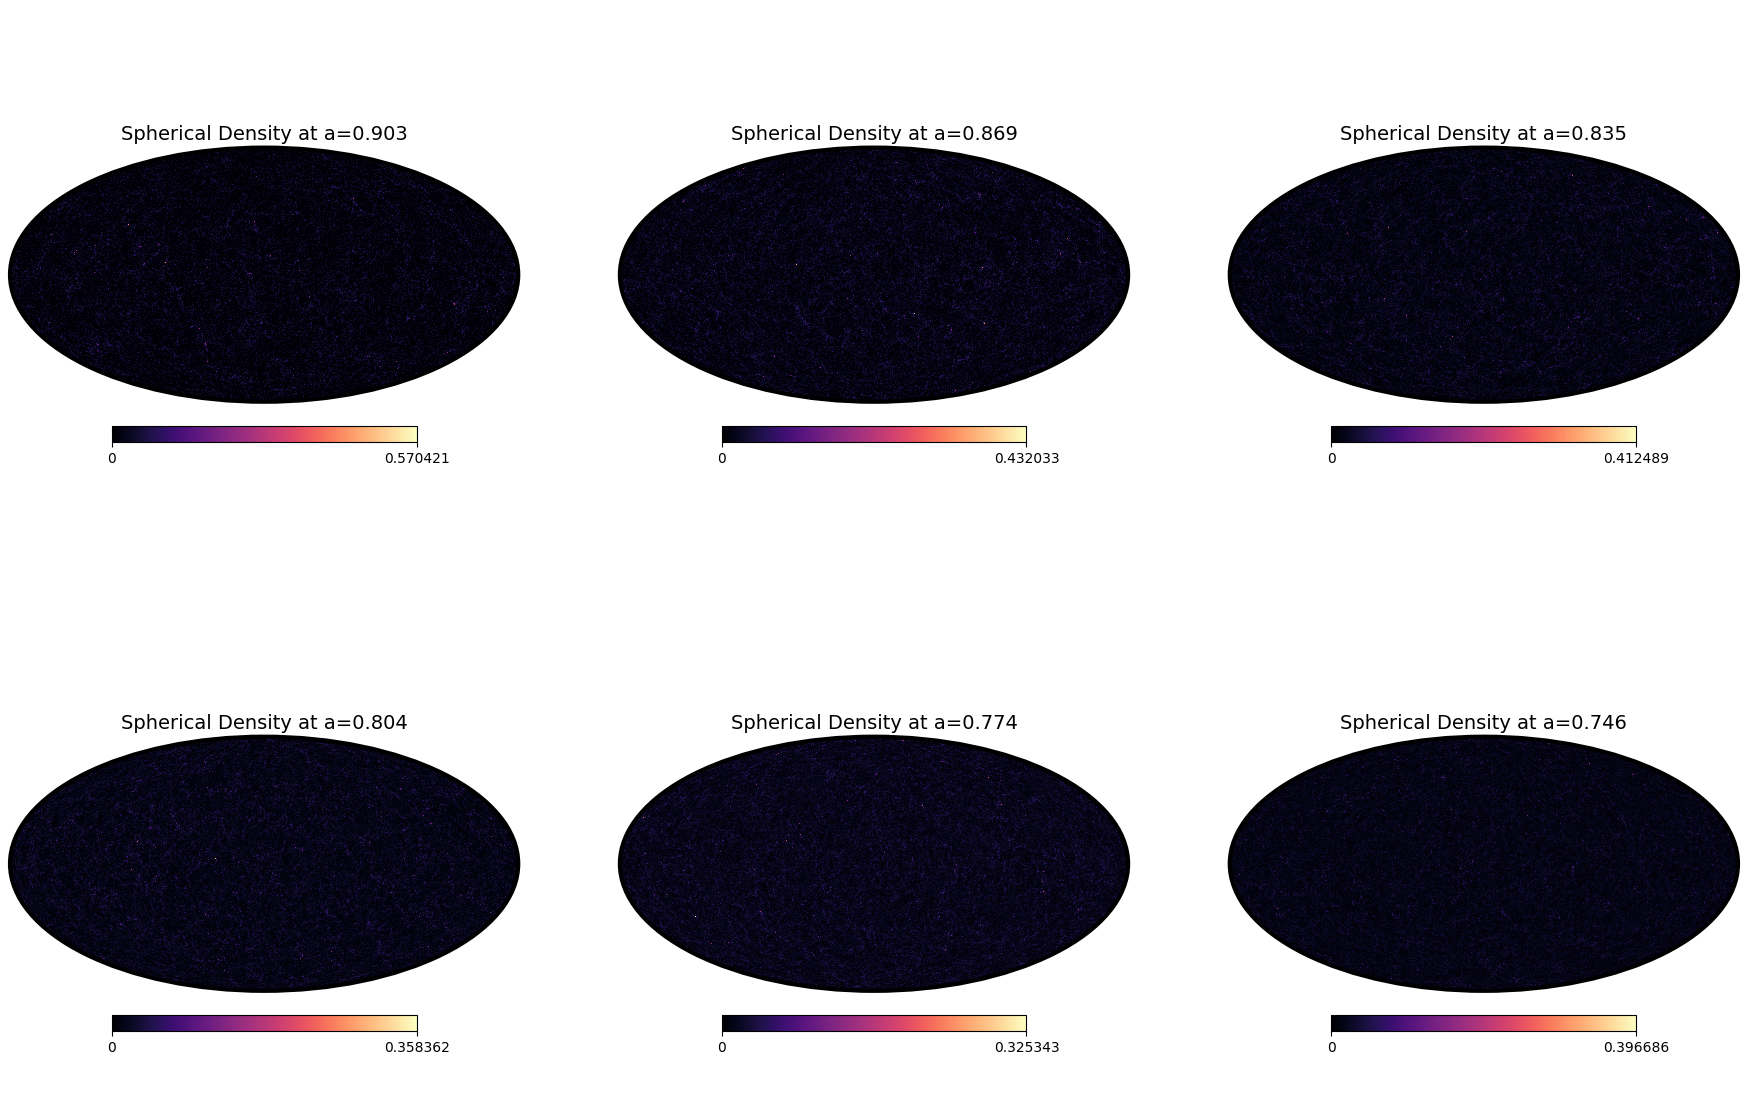

In [6]:
lightcone[-6:].apply_fn(jnp.log1p).show(ncols=3)

## Angular power spectra vs theory

Each shell is converted to **overdensity** (`per_plane`) and compared to the linear
`number_counts` prediction for a top-hat $n(z)$ spanning the shell.

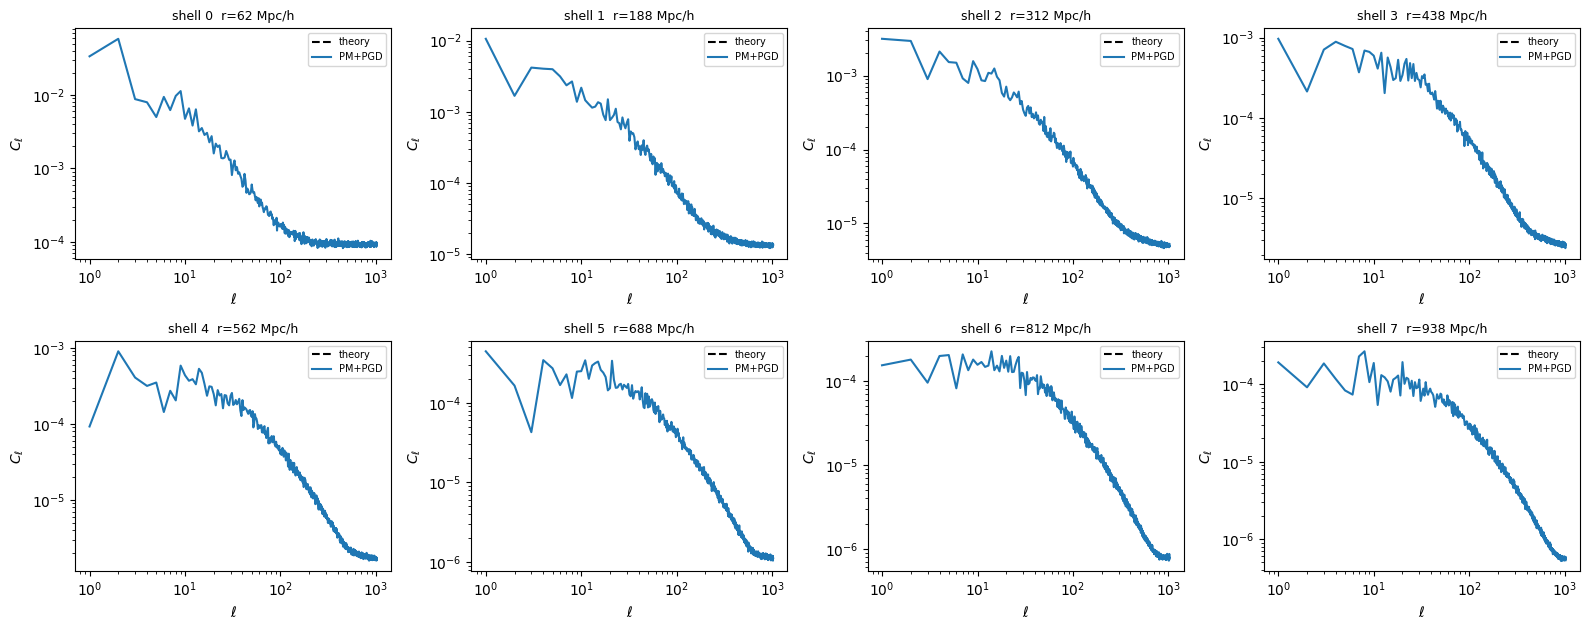

In [7]:
LMAX = 2 * nside
ells = jnp.arange(LMAX)

rc = np.asarray(lightcone.comoving_centers)
rw = np.asarray(lightcone.density_width)
z_near = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc - rw / 2))))
z_far = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc + rw / 2))))
nz_s = [jfli.tophat_z(float(zn), float(zf), gals_per_arcmin2=1.0) for zn, zf in zip(z_far, z_near)]

theory_cl = jfli.compute_theory_cl(
    cosmo, ell=ells, z_source=nz_s, probe_type="number_counts", nonlinear_fn="halofit", cross=False
)
cl_meas = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)

th = np.asarray(theory_cl.array)
me = np.asarray(cl_meas.array)
L = np.arange(1, LMAX)
ncols = 4
nrows = (nb_shells + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.flatten()
for i in range(nb_shells):
    axes[i].loglog(L, th[i, 1:], "k--", label="theory")
    axes[i].loglog(L, me[i, 1:], color="C0", label="PM+PGD")
    axes[i].set_title(f"shell {i}  r={float(rc[i]):.0f} Mpc/h", fontsize=9)
    axes[i].set_xlabel(r"$\ell$")
    axes[i].set_ylabel(r"$C_\ell$")
    axes[i].legend(fontsize=7)
for i in range(nb_shells, len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

## Shell partitioning: equal width vs equal volume

When slicing the lightcone into shells there are several strategies (`shell_spacing=`):

- **`"comoving"` (equal width)** — boundaries evenly spaced in comoving distance ($dr=$ const).
  Simple, but a spherical shell's volume grows as $4\pi r^2\,dr$, so outer shells contain
  disproportionately more particles.
- **`"equal_vol"`** — boundaries chosen so every shell encloses the **same comoving volume**.
  Outer shells are thinner in radius — more uniform statistics across shells.
- **hybrid (equal volume + `min_width` floor)** — pure equal-volume shells become very thin at
  large $r$; `jax_fli` clamps any shell thinner than `min_width` and divides the rest equally.

The diagram below contrasts the three for 8 shells across the box.

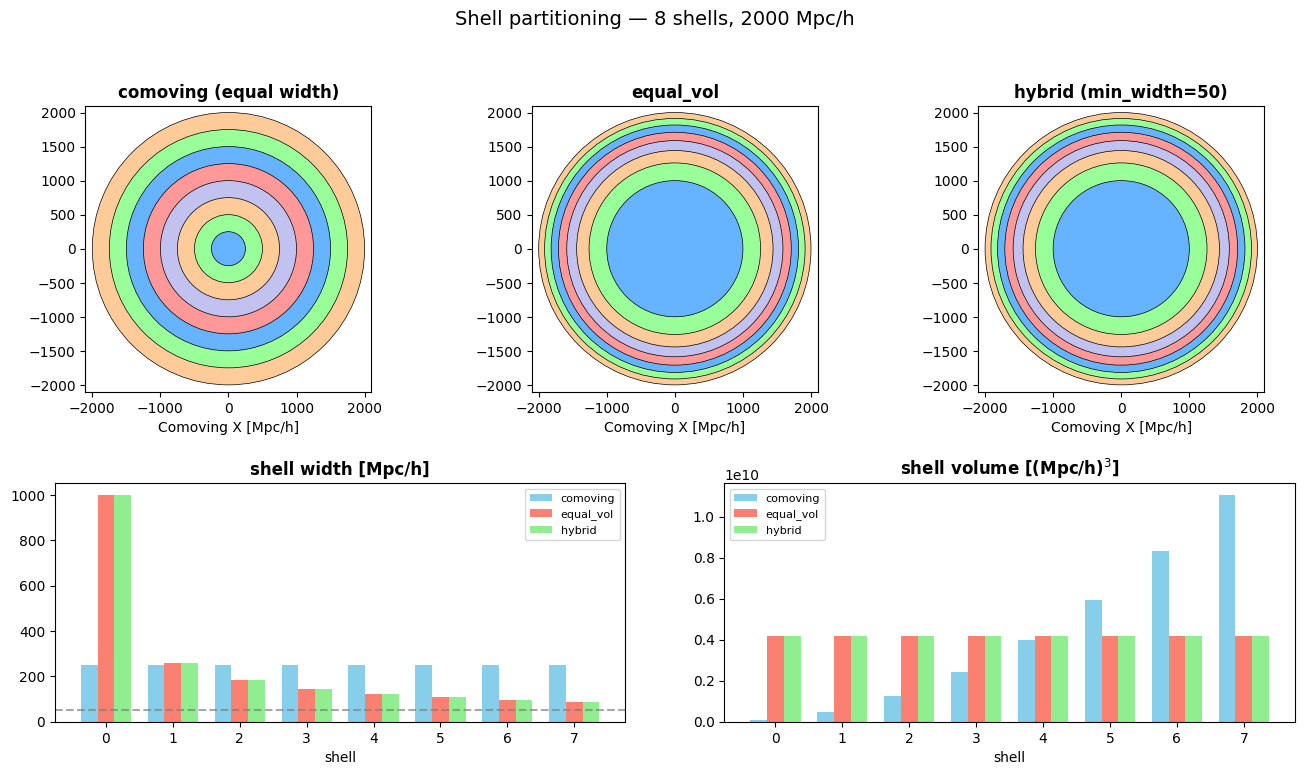

In [8]:
N_vis = nb_shells
R_start, R_end, min_width_vis = 0.0, box_size[0], 50.0


def equal_vol_min_width(R0, R1, N, mw):
    for M in range(N):
        R_split = R1 - M * mw
        N_in = N - M
        if N_in == 0:
            break
        k = jnp.arange(N_in + 1)
        R_in = (R0**3 + (k / N_in) * (R_split**3 - R0**3)) ** (1 / 3)
        if R_in[-1] - R_in[-2] >= mw:
            if M > 0:
                R_out = R_split + jnp.arange(1, M + 1) * mw
                return jnp.concatenate([R_in, R_out])
            return R_in
    return jnp.linspace(R1 - N * mw, R1, N + 1)


R_rad = jnp.linspace(R_start, R_end, N_vis + 1)
R_vol = (R_start**3 + (jnp.arange(N_vis + 1) / N_vis) * (R_end**3 - R_start**3)) ** (1 / 3)
R_hyb = equal_vol_min_width(R_start, R_end, N_vis, min_width_vis)

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 6, height_ratios=[1.2, 1], hspace=0.35, wspace=0.8)


def draw(ax, radii, title):
    colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99", "#c2c2f0"]
    for i in range(len(radii) - 1, 0, -1):
        ax.add_patch(plt.Circle((0, 0), float(radii[i]), color=colors[i % len(colors)], ec="black", lw=0.5))
    ax.set_xlim(-R_end * 1.05, R_end * 1.05)
    ax.set_ylim(-R_end * 1.05, R_end * 1.05)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Comoving X [Mpc/h]")


for col, (R, name) in enumerate(
    [(R_rad, "comoving (equal width)"), (R_vol, "equal_vol"), (R_hyb, f"hybrid (min_width={min_width_vis:.0f})")]
):
    draw(fig.add_subplot(gs[0, 2 * col : 2 * col + 2]), R, name)

x = jnp.arange(N_vis)
bw = 0.25
ax4 = fig.add_subplot(gs[1, 0:3])
ax4.bar(x - bw, jnp.diff(R_rad), bw, label="comoving", color="skyblue")
ax4.bar(x, jnp.diff(R_vol), bw, label="equal_vol", color="salmon")
ax4.bar(x + bw, jnp.diff(R_hyb), bw, label="hybrid", color="lightgreen")
ax4.axhline(min_width_vis, color="gray", ls="--", alpha=0.7)
ax4.set_title("shell width [Mpc/h]", fontweight="bold")
ax4.set_xlabel("shell")
ax4.legend(fontsize=8)
ax5 = fig.add_subplot(gs[1, 3:6])
vol = lambda R: (4 / 3) * jnp.pi * (R[1:] ** 3 - R[:-1] ** 3)
ax5.bar(x - bw, vol(R_rad), bw, label="comoving", color="skyblue")
ax5.bar(x, vol(R_vol), bw, label="equal_vol", color="salmon")
ax5.bar(x + bw, vol(R_hyb), bw, label="hybrid", color="lightgreen")
ax5.set_title("shell volume [(Mpc/h)$^3$]", fontweight="bold")
ax5.set_xlabel("shell")
ax5.legend(fontsize=8)
plt.suptitle(f"Shell partitioning — {N_vis} shells, {R_end:.0f} Mpc/h", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Equal-volume run

We rerun the same pipeline with `shell_spacing="equal_vol"`. Eight equal-volume shells are
naturally thin at the outer edge, so we lower the `min_width` floor accordingly.

In [9]:
lightcone_eq = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="equal_vol", min_width=30.0)
print("equal_vol centers:", np.asarray(lightcone_eq.comoving_centers).round(0))
print("equal_vol widths :", np.asarray(lightcone_eq.density_width).round(0))
print("comoving widths  :", np.asarray(lightcone.density_width).round(0))

equal_vol centers: [250. 565. 676. 757. 824. 882. 933. 978.]
equal_vol widths : [500. 130.  91.  73.  61.  54.  48.  44.]
comoving widths  : [125. 125. 125. 125. 125. 125. 125. 125.]


### Spectra: equal width vs equal volume

Same realization, two slicings. Equal-volume shells hold a more uniform particle count, which
shows up as more consistent shot-noise floors across shells.

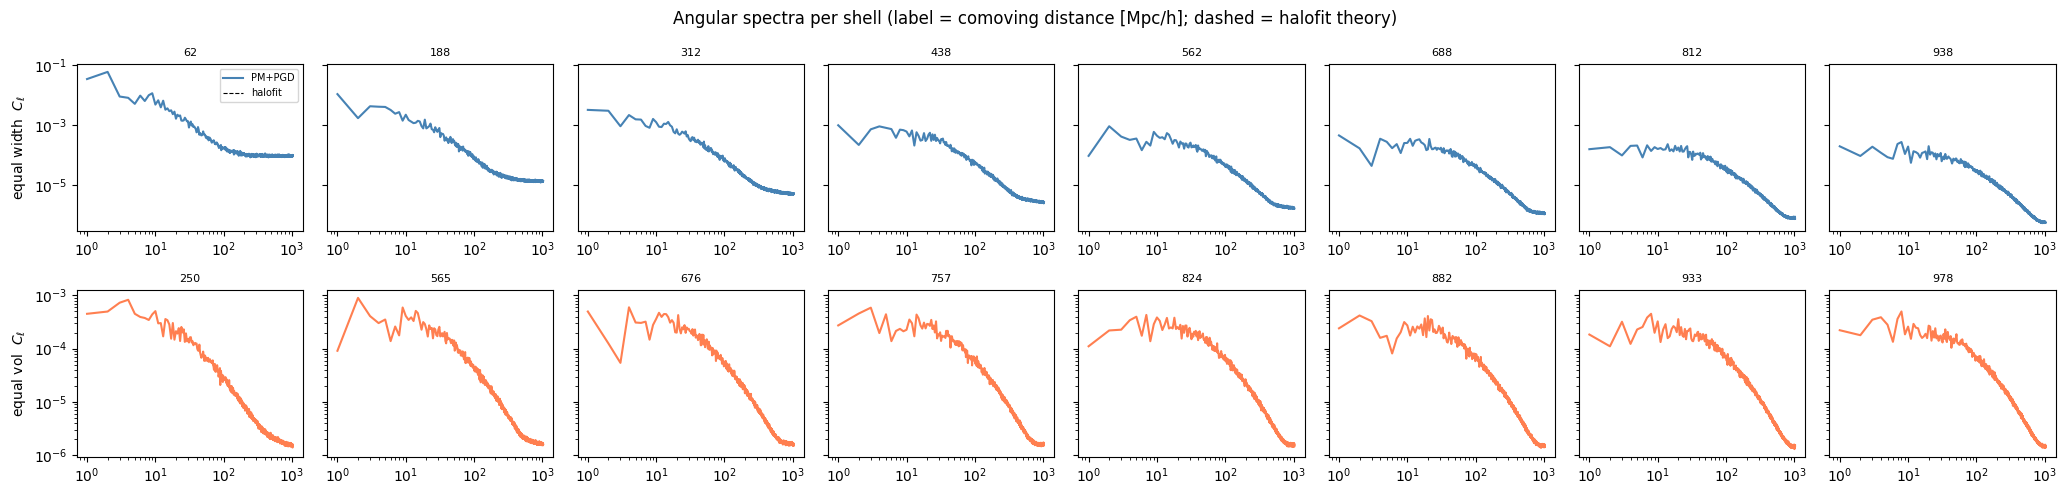

In [10]:
cl_def = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
cl_eq = lightcone_eq.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
A = np.asarray(cl_def.array)
B = np.asarray(cl_eq.array)


def _shell_theory(lc):
    """halofit number-counts C_ell for each shell, n(z) = tophat over the shell edges."""
    rc = np.asarray(lc.comoving_centers)
    rw = np.asarray(lc.density_width)
    z_near = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc - rw / 2))))
    z_far = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc + rw / 2))))
    nz_s = [jfli.tophat_z(float(zn), float(zf), gals_per_arcmin2=1.0) for zn, zf in zip(z_far, z_near)]
    return np.asarray(
        jfli.compute_theory_cl(
            cosmo, ell=ells, z_source=nz_s, probe_type="number_counts", nonlinear_fn="halofit", cross=False
        ).array
    )


th_def = _shell_theory(lightcone)
th_eq = _shell_theory(lightcone_eq)

fig, axes = plt.subplots(2, nb_shells, figsize=(2.6 * nb_shells, 5), sharey="row")
for c in range(nb_shells):
    axes[0, c].loglog(L, A[c, 1:], color="steelblue", label="PM+PGD")
    axes[0, c].loglog(L, th_def[c, 1:], "k--", lw=0.8, label="halofit")
    axes[0, c].set_title(f"{float(lightcone.comoving_centers[c]):.0f}", fontsize=8)
    axes[1, c].loglog(L, B[c, 1:], color="coral")
    axes[1, c].loglog(L, th_eq[c, 1:], "k--", lw=0.8)
    axes[1, c].set_title(f"{float(lightcone_eq.comoving_centers[c]):.0f}", fontsize=8)
axes[0, 0].set_ylabel(r"equal width  $C_\ell$")
axes[1, 0].set_ylabel(r"equal vol  $C_\ell$")
axes[0, 0].legend(fontsize=7)
plt.suptitle("Angular spectra per shell (label = comoving distance [Mpc/h]; dashed = halofit theory)", fontsize=12)
plt.tight_layout()
plt.show()

## Next

[08 &middot; Lensing](08-Lensing.ipynb) turns these spherical density shells into weak-lensing
convergence and shear maps, and saves them to catalogs.